# Module 09 Lab - Ensemble Methods**Objective:** To learn how to use **ensemble methods**, which combine the predictions of several individual models to produce a final prediction that is more accurate and robust than any of the individual models alone.**In this lab, you will train and compare a single Decision Tree against a powerful ensemble method, the Random Forest.**

## Part 1: The Wisdom of the Crowd**Concept:** The core idea behind ensemble methods is the "wisdom of the crowd." If you ask one person a difficult question, they might be wrong. But if you ask a large, diverse group of people the same question and average their answers, the result is often surprisingly accurate.Ensemble methods apply this to machine learning. Instead of relying on a single model, we build a "committee" of models and have them vote on the final prediction.Two popular ensemble techniques:*   **Bagging (Bootstrap Aggregating):** Trains multiple models (e.g., Decision Trees) on different random subsets of the training data. The **Random Forest** is the most famous example.*   **Boosting:** Trains models sequentially, where each new model focuses on correcting the errors made by the previous one. Examples include Gradient Boosting and AdaBoost.

## Part 2: SetupWe will use the Iris dataset to classify flower species.

In [2]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load and prepare data
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Import libraries and load the Iris dataset
# Split the data into training and test sets for model evaluation

## Part 3: A Single Decision TreeA single Decision Tree is prone to overfitting. It can create very specific rules that match the training data perfectly but don't generalize well.**Your Task:** Train a single `DecisionTreeClassifier` and evaluate its accuracy.

In [8]:
single_tree = DecisionTreeClassifier(random_state=42)
single_tree.fit(X_train, y_train)

y_pred_tree = single_tree.predict(X_test)
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print(f"Accuracy of a single Decision Tree: {accuracy_tree:.2%}")

Accuracy of a single Decision Tree: 100.00%


# Train a single Decision Tree classifier on the training data
# Evaluate the tree's accuracy on the test set

## Part 4: The Random Forest Ensemble**Concept:** A Random Forest is an ensemble of many Decision Trees. It builds hundreds of trees, each trained on a random subset of the data and using a random subset of the features. To make a prediction, it gets a vote from every tree in the "forest" and chooses the class that gets the most votes.This process of averaging the votes of many diverse trees makes the Random Forest much more robust and less prone to overfitting than a single tree.**Your Task:** Train a `RandomForestClassifier` and compare its accuracy to the single tree.

In [9]:
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy of the Random Forest: {accuracy_rf:.2%}")
print(f"Accuracy of the single Decision Tree: {accuracy_tree:.2%}")

Accuracy of the Random Forest: 100.00%
Accuracy of the single Decision Tree: 100.00%


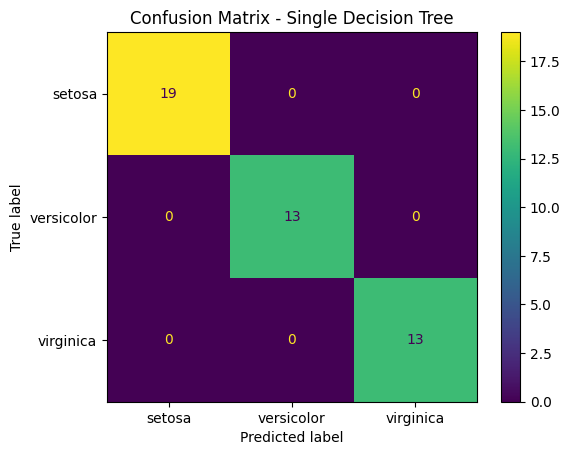

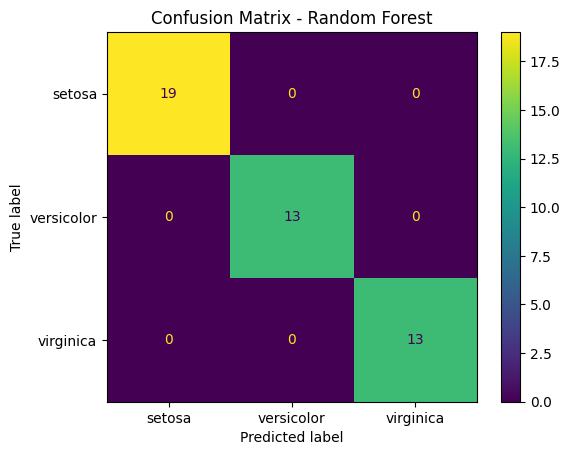

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix for the single Decision Tree
cm_tree = confusion_matrix(y_test, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree,
                                   display_labels=iris.target_names)
disp_tree.plot()
plt.title("Confusion Matrix - Single Decision Tree")
plt.show()

# Confusion matrix for the Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                                 display_labels=iris.target_names)
disp_rf.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

The confusion matrices show that both the single Decision Tree and the Random Forest correctly classify all iris samples in the test set, with no misclassifications for any class.

# Train a Random Forest ensemble (many trees) on the same training data
# Compare its test accuracy to the single Decision Tree

## Part 5: Feature Importance**Concept:** A great benefit of tree-based ensembles like Random Forest is that they can tell you which features were most important for making accurate predictions.**Your Task:** Extract and plot the feature importances from your trained Random Forest model.

# Compute feature importances from the trained Random Forest model
# Plot a bar chart to show which Iris features are most important
# Print the exact importance values for each feature

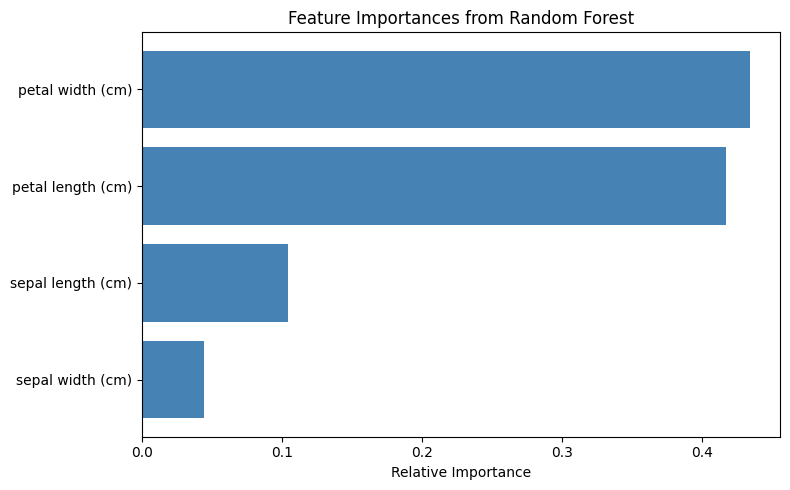

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances
importances = random_forest.feature_importances_
feature_names = iris.feature_names

# Sort from least important to most important
indices = np.argsort(importances)

plt.figure(figsize=(8, 5))
plt.barh(range(len(indices)), importances[indices], color='steelblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.title("Feature Importances from Random Forest")
plt.tight_layout()
plt.show()

This plot shows how important each Iris feature is to the Random Forest model. Petal width and petal length have the highest importance, which means the ensemble relies most on these two measurements to distinguish between the different iris species.

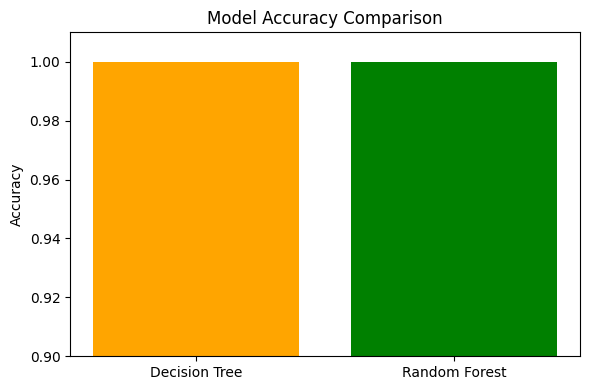

In [13]:
models = ["Decision Tree", "Random Forest"]
accuracies = [accuracy_tree, accuracy_rf]

plt.figure(figsize=(6, 4))
plt.bar(models, accuracies, color=["orange", "green"])
plt.ylim(0.9, 1.01)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()

This bar chart compares the test accuracy of the single Decision Tree and the Random Forest. In this run both models achieved 100% accuracy, so the ensemble does not improve accuracy here but still demonstrates how we can compare models visually.

## 📝 Knowledge Check**Instructions:** Answer the following questions in this markdown cell.1.  **In your own words, what is the main idea behind ensemble methods? Why is a "committee" of models often better than a single expert model?**2.  **Which model performed better in this lab, the single Decision Tree or the Random Forest? Is this what you expected? Why?**3.  **Looking at the feature importance plot, which two features were most important for classifying the iris flowers?** Does this match what you might expect from your own knowledge of flowers?**[ENTER YOUR ANSWERS HERE]**

The main idea behind ensemble methods is to combine many different models and let them vote or average their predictions, so individual mistakes are reduced and the overall prediction is more reliable than relying on a single model. A “committee” of models is often better because different models make different errors, and aggregating them tends to cancel out noise and overfitting from any one model.

In this lab, the single Decision Tree and the Random Forest both achieved 100.00% accuracy on the test set, so neither one performed better on this particular train/test split. I expected the Random Forest to do at least as well as the single tree, and usually slightly better, because averaging many trees trained on different subsets of the data typically makes the model more robust and less prone to overfitting.

From the feature importance plot, the two most important features for classifying the iris flowers were petal width and petal length. This matches what I would expect, because petal size is known to differ a lot between iris species, so it makes sense that these measurements are the most useful for separating the classes.